In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Download the data files
!rm *.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station1_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station2_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station4_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station5_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station6_Revised_Final_Data.csv

In [3]:
# List of stations
stations = {
    'Station1_Revised_Final_Data.csv': 'Station 1',
    'Station2_Revised_Final_Data.csv': 'Station 2',
    'Station3_Revised_Final_Data.csv': 'Station 3',
    'Station4_Revised_Final_Data.csv': 'Station 4',
    'Station5_Revised_Final_Data.csv': 'Station 5',
    'Station6_Revised_Final_Data.csv': 'Station 6'
}

In [4]:
# Load and process SWC data for all stations
import pandas as pd

def load_swc_data_all_stations(files, station_names, swc_col='SWC_5', time='year'):
    """
    Load SWC data for multiple stations and return a combined pivot table.
    
    Args:
        files: List of file paths, one per station
        station_names: List of station names (must match length of files)
        swc_col: Column name for soil water content (e.g., 'SWC_5')
        time: One of ['year', 'month', 'month_matrix']
    
    Returns:
        DataFrame with years or months as index and stations as columns
    """
    all_data = []

    for file, station in zip(files, station_names):
        df = pd.read_csv(file, index_col=0, parse_dates=True)
        df.reset_index(inplace=True)
        df.rename(columns={'index': 'Date'}, inplace=True)
        
        if time == 'year':
            df['Group'] = df['Date'].dt.year
            summary = df.groupby('Group')[swc_col].mean().reset_index()
            summary.columns = [time.title(), station]
            summary.set_index(time.title(), inplace=True)
            all_data.append(summary)
        
        elif time == 'month_matrix':
            df['Year'] = df['Date'].dt.year
            df['Month'] = df['Date'].dt.month_name()
            df['Month_num'] = df['Date'].dt.month
            monthly_avgs = (
                df.groupby(['Year', 'Month', 'Month_num'])[swc_col]
                .mean()
                .reset_index()
            )
            matrix = monthly_avgs.pivot_table(index='Month', columns='Year', values=swc_col)
            ordered_months = [
                'January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December'
            ]
            matrix = matrix.reindex(ordered_months)
            matrix.columns.name = None
            matrix.index.name = 'Month'
            matrix.columns = [f"{station}_{col}" for col in matrix.columns]
            all_data.append(matrix)
        
        else:
            raise ValueError("`time` must be 'year' or 'month_matrix' for this function.")

    # Combine all stations' data
    if time == 'year':
        combined_df = pd.concat(all_data, axis=1)
    elif time == 'month_matrix':
        combined_df = pd.concat(all_data, axis=1)

    return combined_df

In [5]:
files = list(stations.keys())
station_names = list(stations.values())

swc5_all_stations = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_5',
    time='year'
)
swc5_all_stations_month = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_5',
    time='month_matrix'
)

swc10_all_stations = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_10',
    time='year'
)
swc10_all_stations_month = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_10',
    time='month_matrix'
)

swc20_all_stations = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_20',
    time='year'
)
swc20_all_stations_month = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_20',
    time='month_matrix'
)
swc50_all_stations = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_50',
    time='year'
)
swc50_all_stations_month = load_swc_data_all_stations(
    files, station_names,
    swc_col='SWC_50',
    time='month_matrix'
)

In [6]:
swc5_all_stations.head()

,Station 1,Station 2,Station 3,Station 4,Station 5,Station 6
Year,,,,,,
2015,0.120606,0.185836,0.174577,0.198561,0.257076,0.103533
2016,0.139630,0.185565,0.171189,0.212058,0.256079,0.106851
2017,0.147621,0.169389,0.162026,0.205240,0.238340,0.101532
2018,0.146292,0.191040,0.169121,0.210875,0.242707,0.115244
2019,0.142953,0.178087,0.162858,0.192395,0.256886,0.121277


In [7]:
swc5_all_stations_month.head()

,Station 1_2015,Station 1_2016,Station 1_2017,Station 1_2018,Station 1_2019,Station 1_2020,Station 2_2015,Station 2_2016,Station 2_2017,Station 2_2018,...,Station 5_2017,Station 5_2018,Station 5_2019,Station 5_2020,Station 6_2015,Station 6_2016,Station 6_2017,Station 6_2018,Station 6_2019,Station 6_2020
Month,,,,,,,,,,,,,,,,,,,,,
January,0.165465,0.146950,0.182347,0.155863,0.193766,0.176367,0.245449,0.231649,0.225563,0.202319,...,0.296496,0.257122,0.357575,0.270883,0.128310,0.121630,0.121766,0.111082,0.152841,0.141953
February,0.135112,0.100454,0.175009,0.155112,0.179926,0.199188,0.225826,0.140409,0.244686,0.192771,...,0.298499,0.257741,0.332176,0.299890,0.112707,0.099720,0.116814,0.115433,0.140405,0.147193
March,0.161151,0.133176,0.161575,0.145380,0.134036,0.199926,0.231933,0.220730,0.200481,0.198456,...,0.292934,0.259355,0.311913,0.304481,0.125059,0.107159,0.108860,0.104708,0.109969,0.147870
April,0.112149,0.167800,0.126635,0.111433,0.139426,0.172165,0.187190,0.209479,0.151704,0.150231,...,0.258528,0.206607,0.275375,0.283646,0.096881,0.118617,0.097001,0.089203,0.117194,0.132743
May,0.154694,0.152665,0.140253,0.147053,0.161535,0.161712,0.240828,0.214593,0.133187,0.168852,...,0.226421,0.235993,0.312794,0.269595,0.123778,0.110325,0.091782,0.106485,0.130372,0.124474


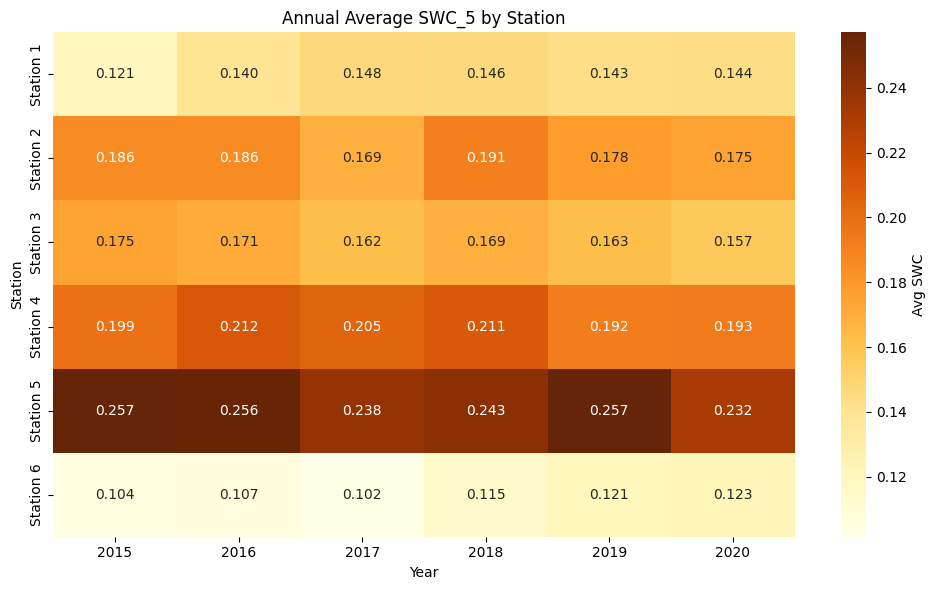

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc5_all_stations.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_5 by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

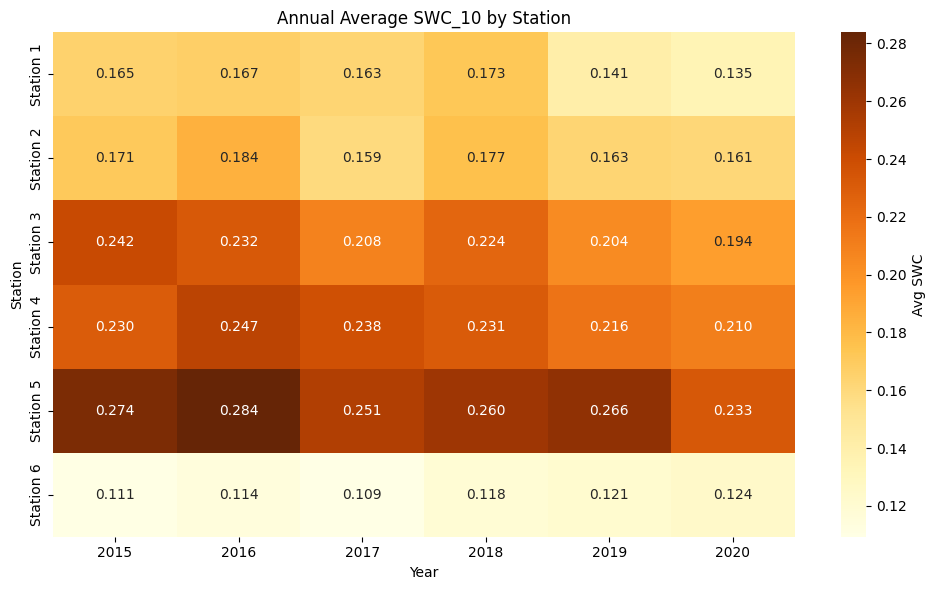

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc10_all_stations.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_10 by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

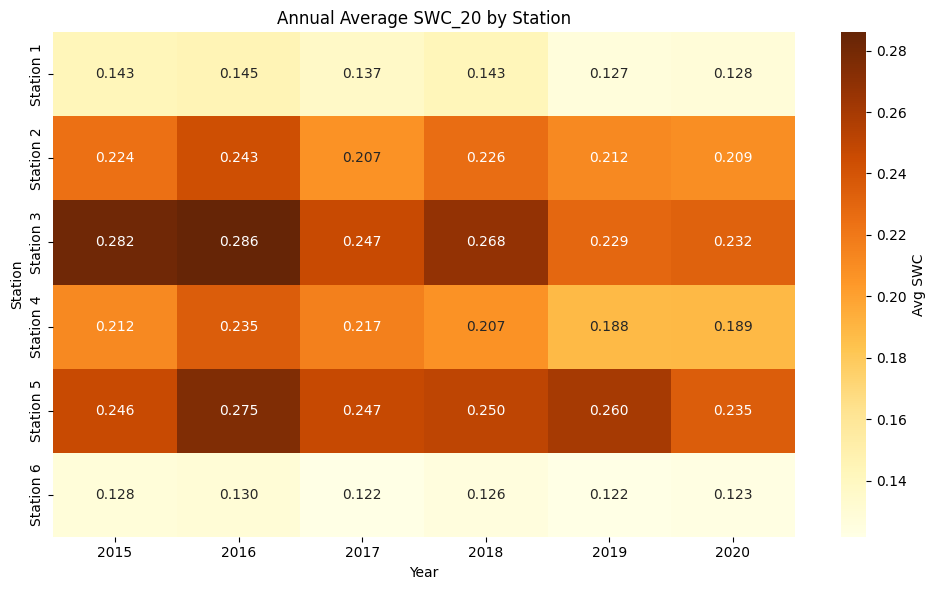

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc20_all_stations.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_20 by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

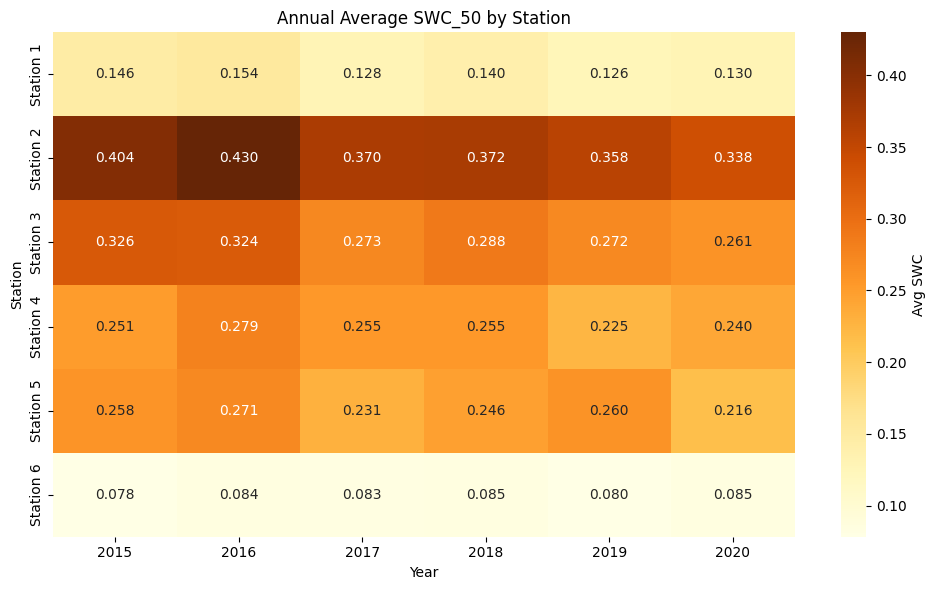

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc50_all_stations.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_50 by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

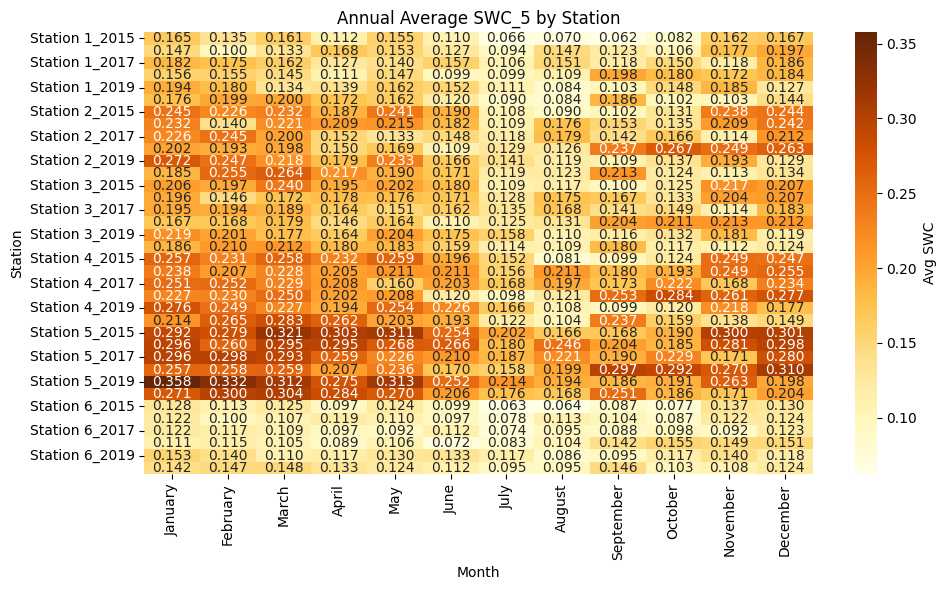

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc5_all_stations_month.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_5 by Station")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

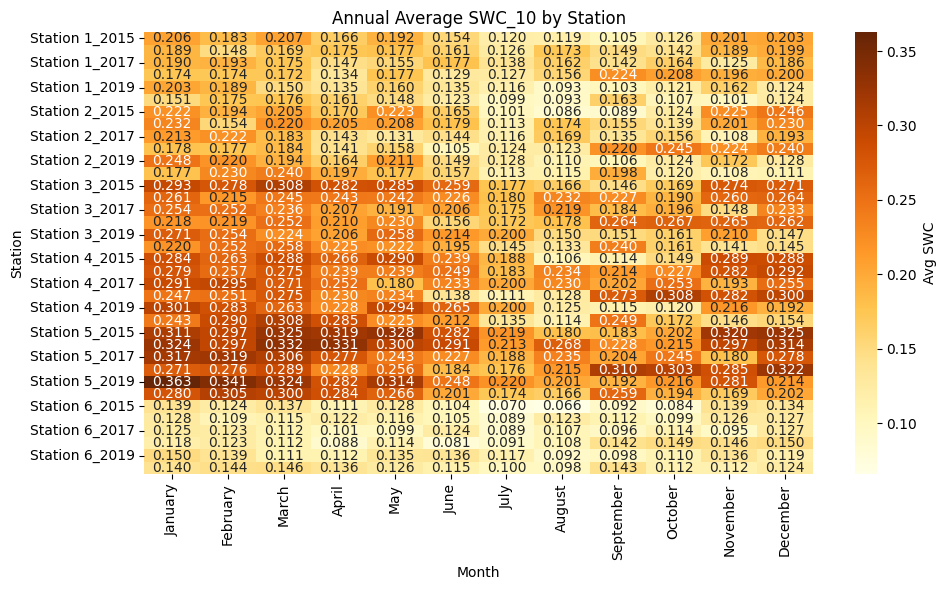

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc10_all_stations_month.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_10 by Station")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

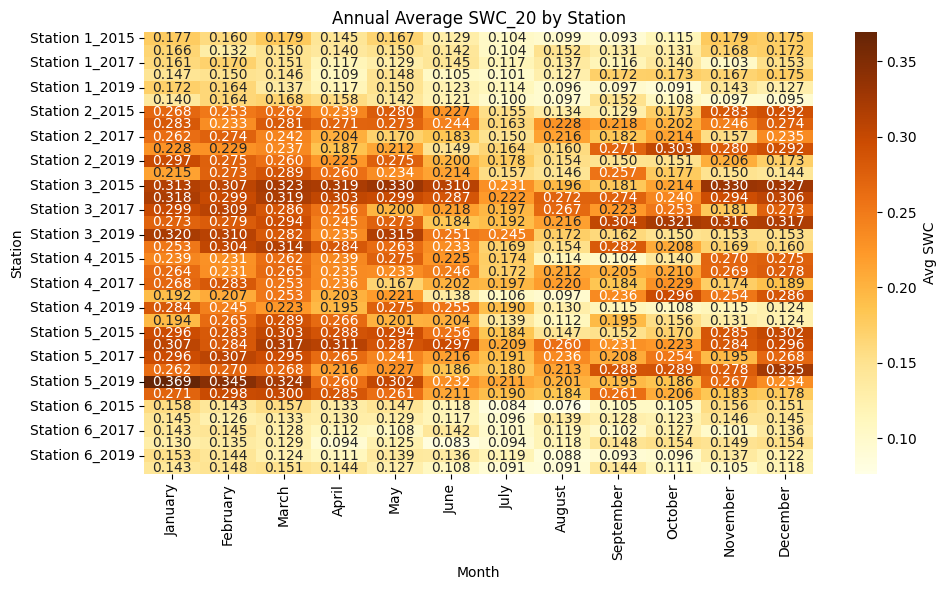

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc20_all_stations_month.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_20 by Station")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

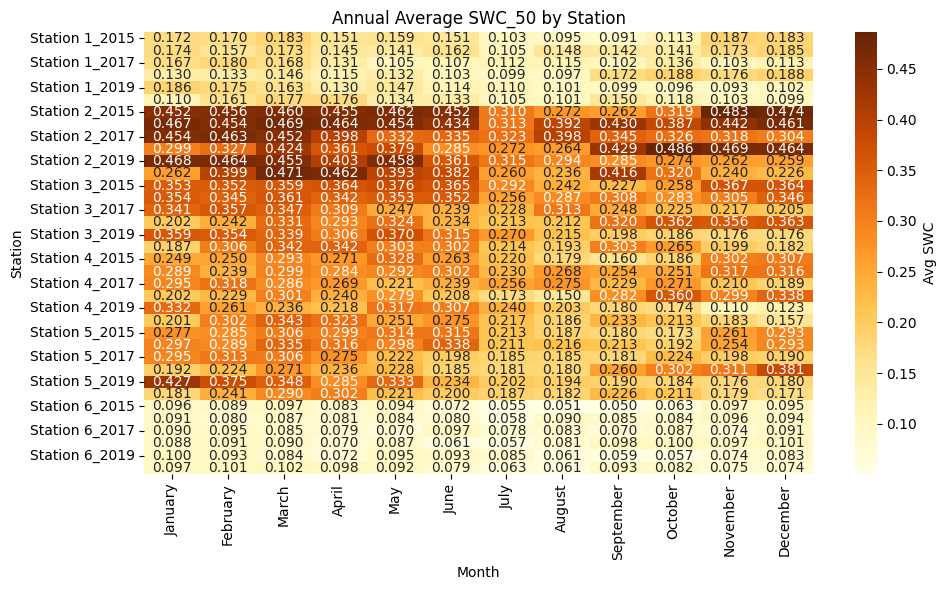

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(swc50_all_stations_month.T, cmap="YlOrBr", annot=True, fmt=".3f", cbar_kws={'label': 'Avg SWC'})
plt.title("Annual Average SWC_50 by Station")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

# Kruskal–Wallis Test

## Why Use Kruskal–Wallis?
The Kruskal–Wallis test is a non-parametric alternative to one-way ANOVA. It is used to determine whether multiple groups (e.g., rainfall across years or months) come from the same distribution without assuming normality.

## Method

The rainfall data was grouped by year.
The Kruskal–Wallis test was applied to compare distributions across groups.

The null hypothesis (H₀): all groups come from the same distribution.
The alternative hypothesis (H₁): at least one group differs.

## Interpretation

A p-value < 0.05 → reject H₀ → rainfall distributions differ significantly across groups.
A p-value ≥ 0.05 → fail to reject H₀ → no significant difference across groups.

## Conclusion
There is a statistically significant difference between soil moisture between stations throughout the different levels, but there is no statistically significant difference between the years.

In [16]:
from scipy.stats import kruskal

# Assuming swc5_all_stations is already loaded:
# Rows = Years, Columns = Stations

# 1. Kruskal-Wallis test across stations (all years)
station_groups = [swc5_all_stations[station].dropna().values for station in swc5_all_stations.columns]
kruskal_stations_stat, kruskal_stations_p = kruskal(*station_groups)

# 2. Kruskal-Wallis test across years (all stations)
year_groups = [swc5_all_stations.loc[year].dropna().values for year in swc5_all_stations.index]
kruskal_years_stat, kruskal_years_p = kruskal(*year_groups)

# Compile results
kruskal_results = pd.DataFrame({
    'Test': ['Across Stations (all years)', 'Across Years (all stations)'],
    'H-statistic': [round(kruskal_stations_stat, 3), round(kruskal_years_stat, 3)],
    'P-value': [round(kruskal_stations_p, 4), round(kruskal_years_p, 4)],
    'Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [kruskal_stations_p, kruskal_years_p]]
})

print(kruskal_results)


                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)       33.646   0.0000                    Yes
1  Across Years (all stations)        0.177   0.9993                     No


In [17]:
# 1. Kruskal-Wallis test across stations (all years)
station_groups = [swc10_all_stations[station].dropna().values for station in swc10_all_stations.columns]
kruskal_stations_stat, kruskal_stations_p = kruskal(*station_groups)

# 2. Kruskal-Wallis test across years (all stations)
year_groups = [swc10_all_stations.loc[year].dropna().values for year in swc10_all_stations.index]
kruskal_years_stat, kruskal_years_p = kruskal(*year_groups)

# Compile results
kruskal_results = pd.DataFrame({
    'Test': ['Across Stations (all years)', 'Across Years (all stations)'],
    'H-statistic': [round(kruskal_stations_stat, 3), round(kruskal_years_stat, 3)],
    'P-value': [round(kruskal_stations_p, 4), round(kruskal_years_p, 4)],
    'Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [kruskal_stations_p, kruskal_years_p]]
})

print(kruskal_results)

                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)       31.886   0.0000                    Yes
1  Across Years (all stations)        1.495   0.9136                     No


In [18]:
# 1. Kruskal-Wallis test across stations (all years)
station_groups = [swc20_all_stations[station].dropna().values for station in swc20_all_stations.columns]
kruskal_stations_stat, kruskal_stations_p = kruskal(*station_groups)

# 2. Kruskal-Wallis test across years (all stations)
year_groups = [swc20_all_stations.loc[year].dropna().values for year in swc20_all_stations.index]
kruskal_years_stat, kruskal_years_p = kruskal(*year_groups)

# Compile results
kruskal_results = pd.DataFrame({
    'Test': ['Across Stations (all years)', 'Across Years (all stations)'],
    'H-statistic': [round(kruskal_stations_stat, 3), round(kruskal_years_stat, 3)],
    'P-value': [round(kruskal_stations_p, 4), round(kruskal_years_p, 4)],
    'Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [kruskal_stations_p, kruskal_years_p]]
})

print(kruskal_results)

                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)       30.895   0.0000                    Yes
1  Across Years (all stations)        2.790   0.7324                     No


In [19]:
# 1. Kruskal-Wallis test across stations (all years)
station_groups = [swc50_all_stations[station].dropna().values for station in swc50_all_stations.columns]
kruskal_stations_stat, kruskal_stations_p = kruskal(*station_groups)

# 2. Kruskal-Wallis test across years (all stations)
year_groups = [swc50_all_stations.loc[year].dropna().values for year in swc50_all_stations.index]
kruskal_years_stat, kruskal_years_p = kruskal(*year_groups)

# Compile results
kruskal_results = pd.DataFrame({
    'Test': ['Across Stations (all years)', 'Across Years (all stations)'],
    'H-statistic': [round(kruskal_stations_stat, 3), round(kruskal_years_stat, 3)],
    'P-value': [round(kruskal_stations_p, 4), round(kruskal_years_p, 4)],
    'Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [kruskal_stations_p, kruskal_years_p]]
})

print(kruskal_results)

                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)       32.471   0.0000                    Yes
1  Across Years (all stations)        1.213   0.9436                     No


# Autocorrelation Test for Seasonality (ACF)

This section uses the autocorrelation function (ACF) to detect seasonal patterns in monthly rainfall (or SWC) at each station.

## Why Use ACF?

The ACF helps identify whether patterns repeat at regular intervals — for example, every 12 months, which indicates annual seasonality.

## Method

Monthly matrices were flattened into a 1D time series (month-by-month across years) per station.
The autocorrelation at lag 12 was extracted to check for annual seasonality.
A correlation at lag 12 greater than the 95% confidence threshold was marked as "Seasonal Signal: Yes".

## Interpretation

Lag-12 correlation > 95% CI → evidence of annual seasonality.
Lag-12 correlation within the 95% CI → no strong evidence of annual seasonality.

## Conclusion

Across Stations 2–6, the lag-12 autocorrelations are not statistically significant because they remain inside the confidence bounds. 
All stations show positive correlations at short lags (1–6 months). This suggests short-term memory: soil water content in one month is moderately influenced by the previous several months.
Beyond ~18 months, many stations show negative autocorrelation. This means when soil moisture was high 18–30 months ago, it is more likely to be lower today. This could reflect multi-year cycles or the impact of alternating wet/dry years.

<Figure size 1000x400 with 0 Axes>

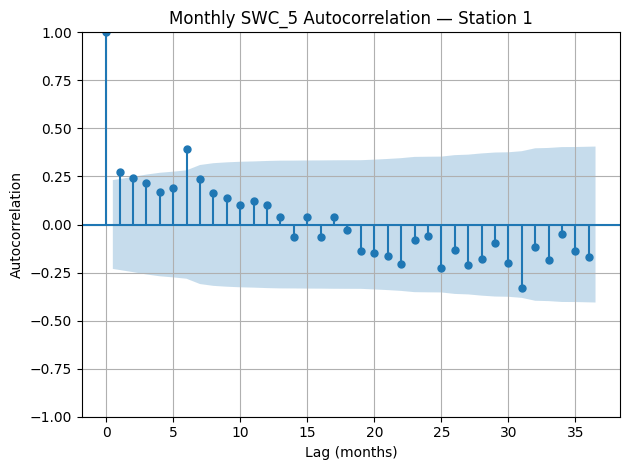

<Figure size 1000x400 with 0 Axes>

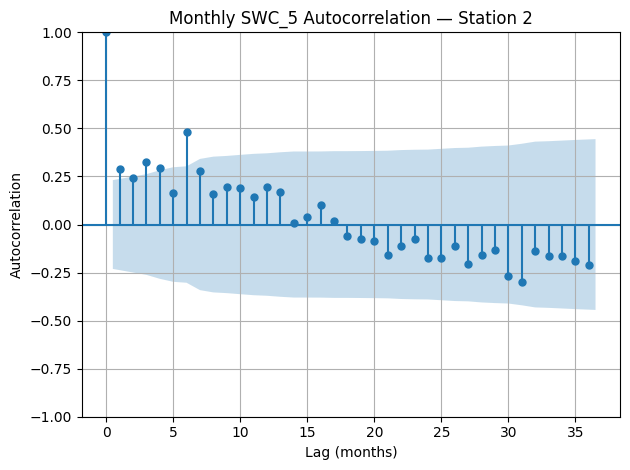

<Figure size 1000x400 with 0 Axes>

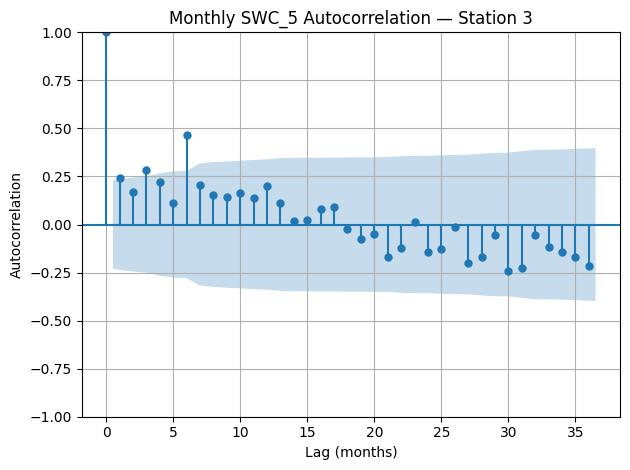

<Figure size 1000x400 with 0 Axes>

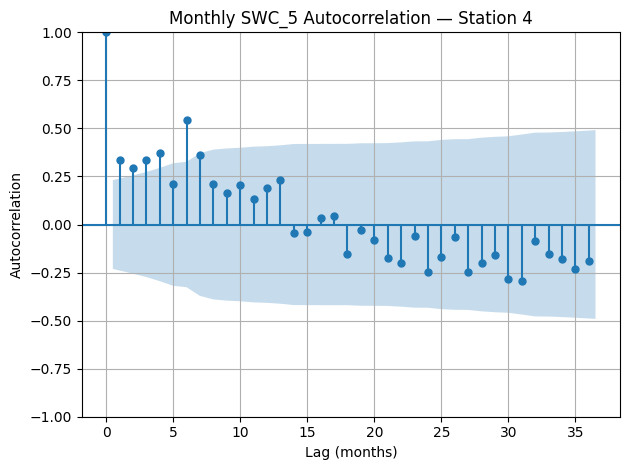

<Figure size 1000x400 with 0 Axes>

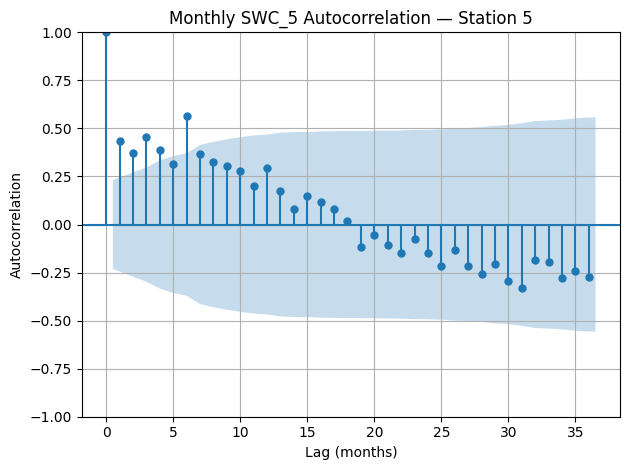

<Figure size 1000x400 with 0 Axes>

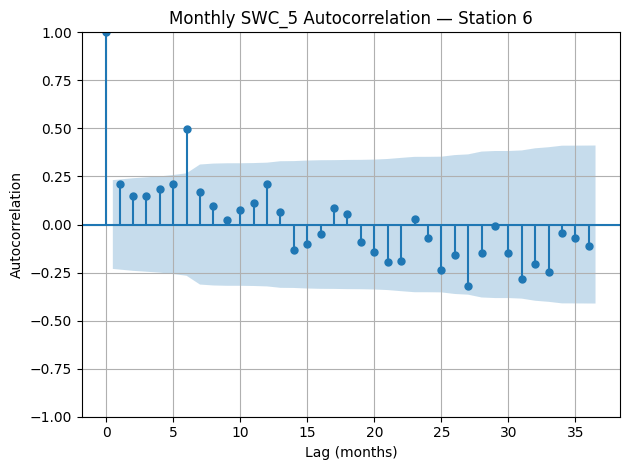

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

# Loop through each station and generate ACF plot for monthly SWC_5
for file, station_name in stations.items():
    # Load monthly SWC_5 matrix (rows = months, cols = years)
    month_matrix = load_swc_data_all_stations(
    files=[file], 
    station_names=[station_name], 
    swc_col='SWC_5', 
    time='month_matrix'
    )

    # Convert matrix into a 1D time series (month-by-month across years)
    monthly_series = month_matrix.values.flatten()
    monthly_series = pd.Series(monthly_series).dropna()

    # Plot ACF
    plt.figure(figsize=(10, 4))
    plot_acf(monthly_series, lags=36)
    plt.title(f"Monthly SWC_5 Autocorrelation — {station_name}")
    plt.xlabel("Lag (months)")
    plt.ylabel("Autocorrelation")
    plt.grid(True)
    plt.tight_layout()
    filename = f"Monthly_SWC_5_Autocorrelation_{station_name.replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf")
    plt.show()

<Figure size 1000x400 with 0 Axes>

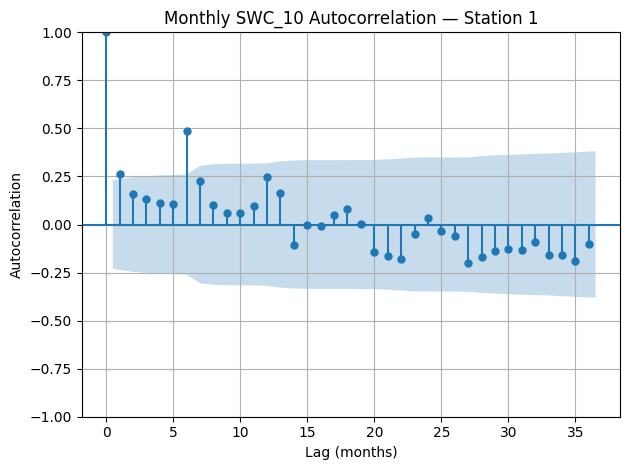

<Figure size 1000x400 with 0 Axes>

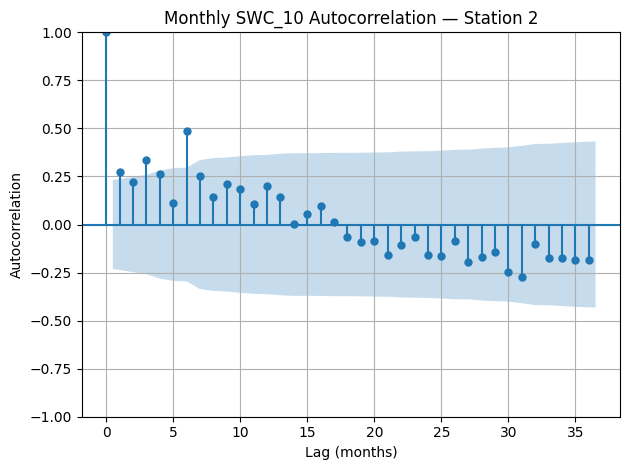

<Figure size 1000x400 with 0 Axes>

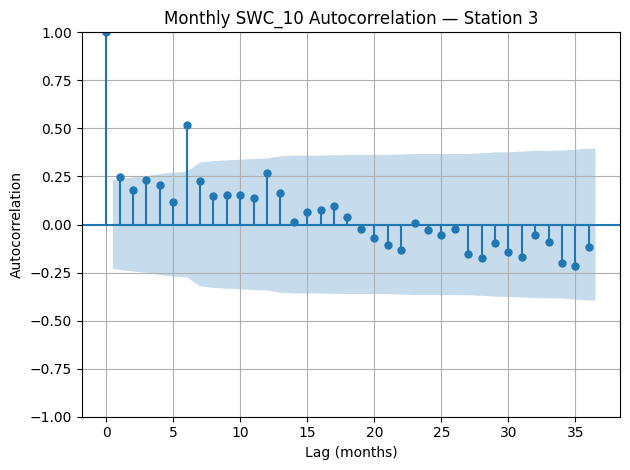

<Figure size 1000x400 with 0 Axes>

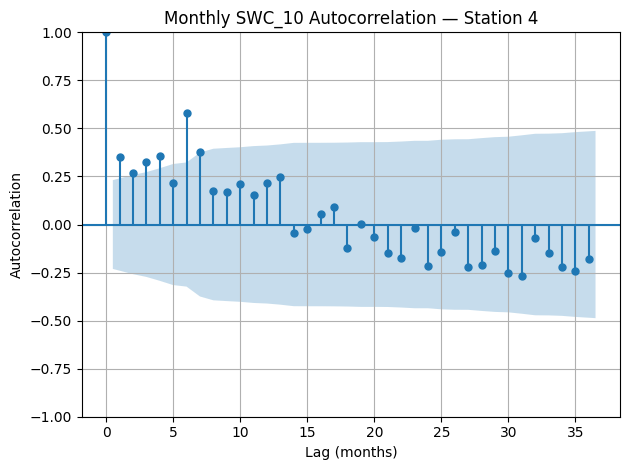

<Figure size 1000x400 with 0 Axes>

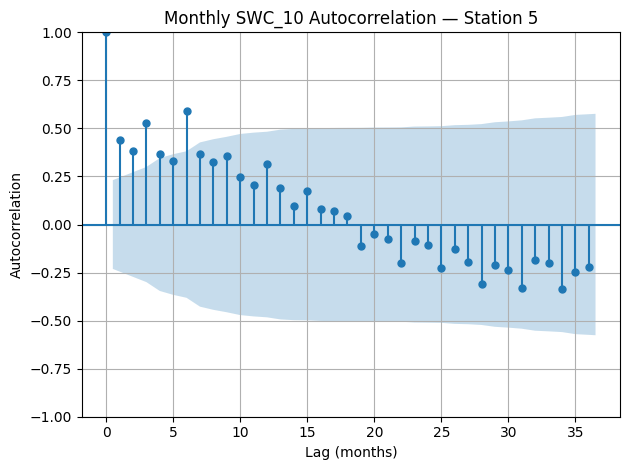

<Figure size 1000x400 with 0 Axes>

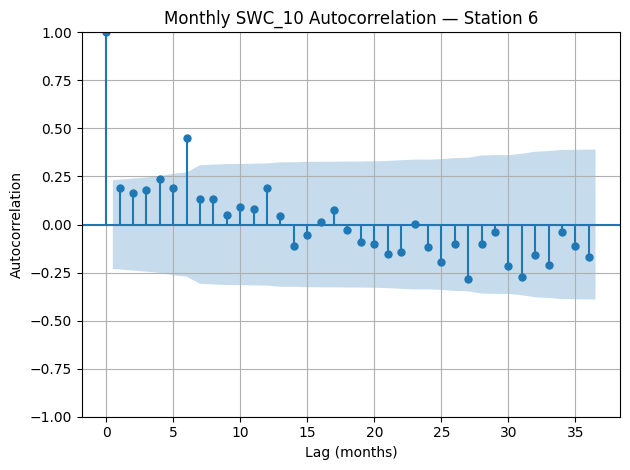

In [21]:
# Loop through each station and generate ACF plot for monthly SWC_10
for file, station_name in stations.items():
    # Load monthly SWC_10 matrix (rows = months, cols = years)
    month_matrix = load_swc_data_all_stations(
    files=[file], 
    station_names=[station_name], 
    swc_col='SWC_10', 
    time='month_matrix'
    )

    # Convert matrix into a 1D time series (month-by-month across years)
    monthly_series = month_matrix.values.flatten()
    monthly_series = pd.Series(monthly_series).dropna()

    # Plot ACF
    plt.figure(figsize=(10, 4))
    plot_acf(monthly_series, lags=36)
    plt.title(f"Monthly SWC_10 Autocorrelation — {station_name}")
    plt.xlabel("Lag (months)")
    plt.ylabel("Autocorrelation")
    plt.grid(True)
    plt.tight_layout()
    filename = f"Monthly_SWC_10_Autocorrelation_{station_name.replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf")
    plt.show()

<Figure size 1000x400 with 0 Axes>

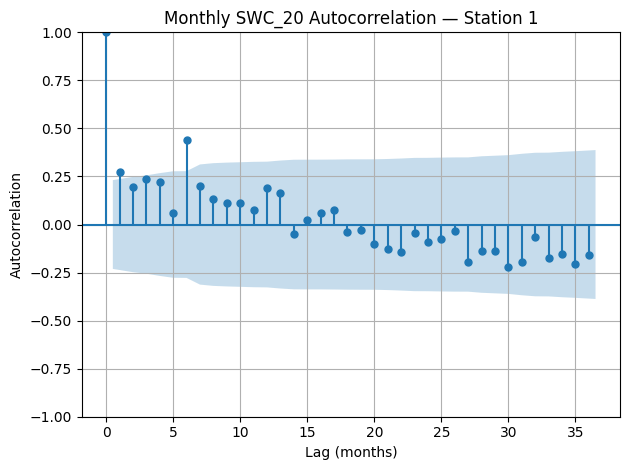

<Figure size 1000x400 with 0 Axes>

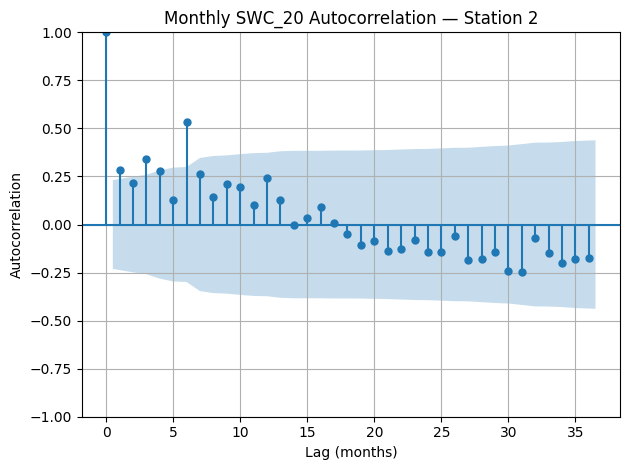

<Figure size 1000x400 with 0 Axes>

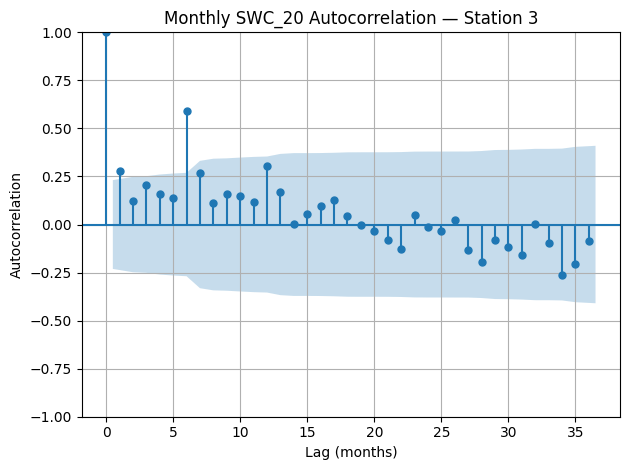

<Figure size 1000x400 with 0 Axes>

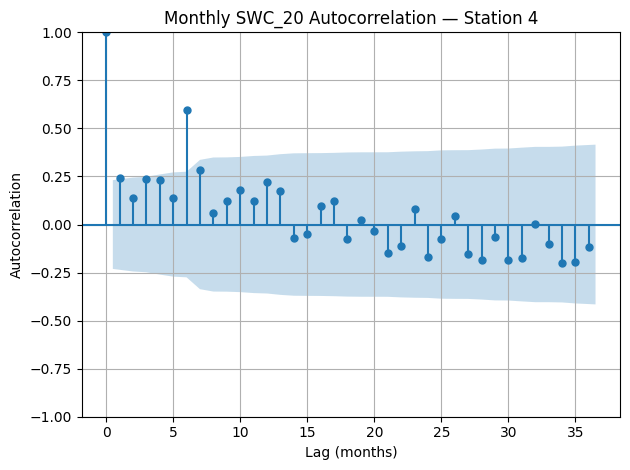

<Figure size 1000x400 with 0 Axes>

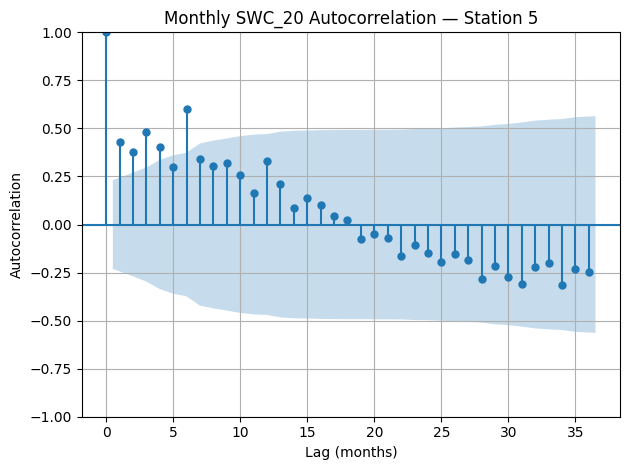

<Figure size 1000x400 with 0 Axes>

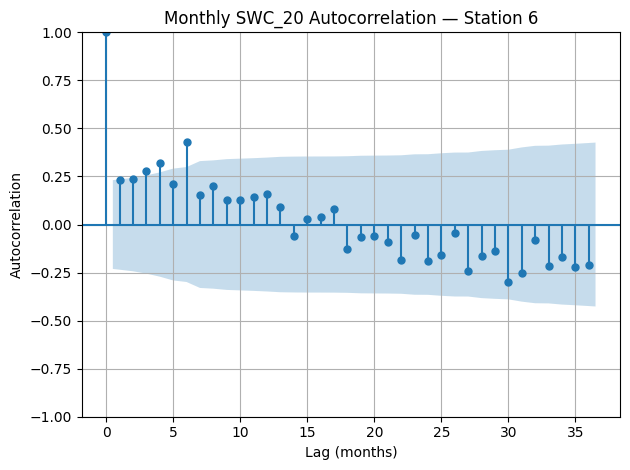

In [22]:
# Loop through each station and generate ACF plot for monthly SWC_20
for file, station_name in stations.items():
    # Load monthly SWC_20 matrix (rows = months, cols = years)
    month_matrix = load_swc_data_all_stations(
    files=[file], 
    station_names=[station_name], 
    swc_col='SWC_20', 
    time='month_matrix'
    )

    # Convert matrix into a 1D time series (month-by-month across years)
    monthly_series = month_matrix.values.flatten()
    monthly_series = pd.Series(monthly_series).dropna()

    # Plot ACF
    plt.figure(figsize=(10, 4))
    plot_acf(monthly_series, lags=36)
    plt.title(f"Monthly SWC_20 Autocorrelation — {station_name}")
    plt.xlabel("Lag (months)")
    plt.ylabel("Autocorrelation")
    plt.grid(True)
    plt.tight_layout()
    filename = f"Monthly_SWC_20_Autocorrelation_{station_name.replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf")
    plt.show()

<Figure size 1000x400 with 0 Axes>

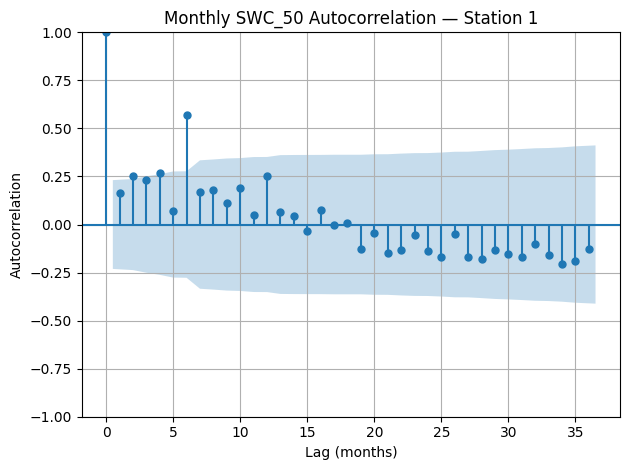

<Figure size 1000x400 with 0 Axes>

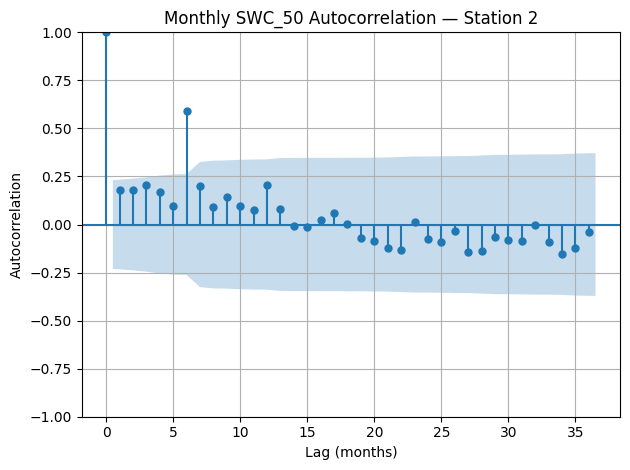

<Figure size 1000x400 with 0 Axes>

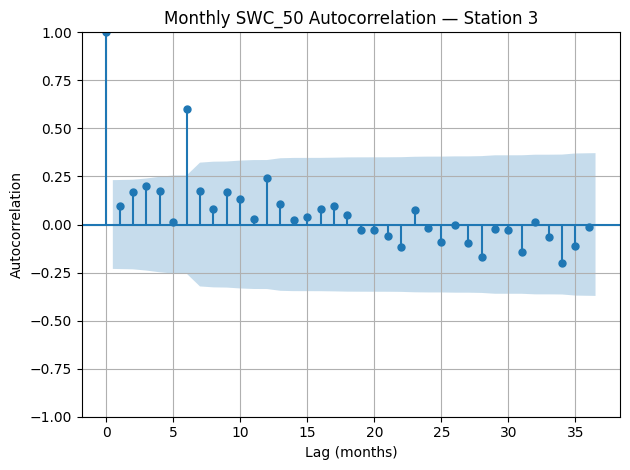

<Figure size 1000x400 with 0 Axes>

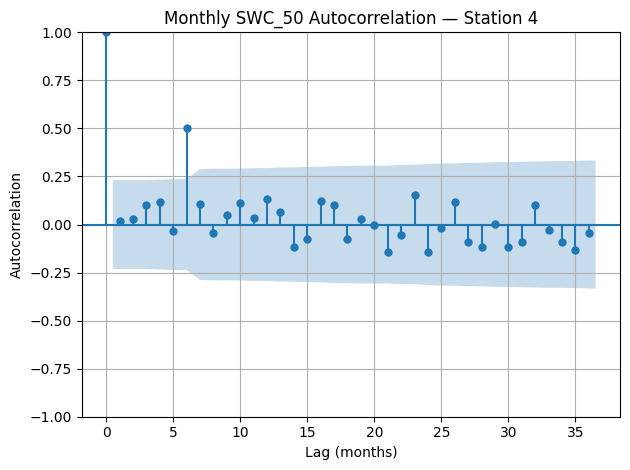

<Figure size 1000x400 with 0 Axes>

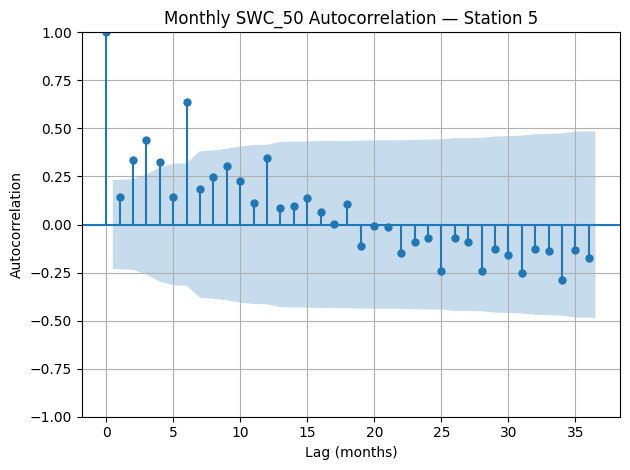

<Figure size 1000x400 with 0 Axes>

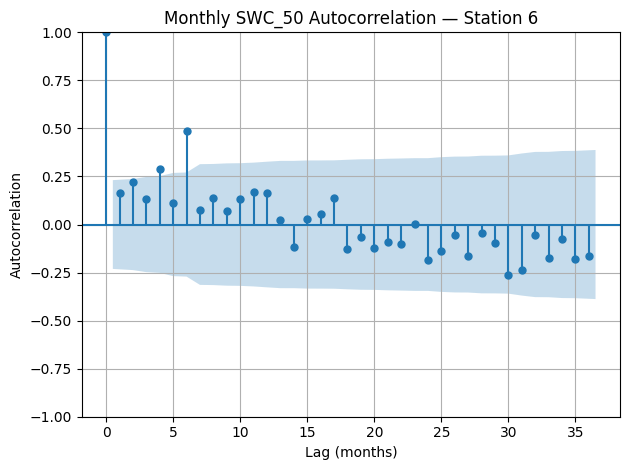

In [23]:
# Loop through each station and generate ACF plot for monthly SWC_50
for file, station_name in stations.items():
    # Load monthly SWC_50 matrix (rows = months, cols = years)
    month_matrix = load_swc_data_all_stations(
    files=[file], 
    station_names=[station_name], 
    swc_col='SWC_50', 
    time='month_matrix'
    )

    # Convert matrix into a 1D time series (month-by-month across years)
    monthly_series = month_matrix.values.flatten()
    monthly_series = pd.Series(monthly_series).dropna()

    # Plot ACF
    plt.figure(figsize=(10, 4))
    plot_acf(monthly_series, lags=36)
    plt.title(f"Monthly SWC_50 Autocorrelation — {station_name}")
    plt.xlabel("Lag (months)")
    plt.ylabel("Autocorrelation")
    plt.grid(True)
    plt.tight_layout()
    filename = f"Monthly_SWC_50_Autocorrelation_{station_name.replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf")
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e560f6b-1726-4372-a865-7294f65e8413' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>